# Video Background–Foreground Decomposition: Robust Principal Component Analysis (IALM) (Robust PCA)

This notebook isolates **Robust PCA** from the original messy pipeline and evaluates it cleanly on:

1. **Simulated data** — a synthetic surveillance video (controlled, known low-rank + sparse structure)
2. **Generalization data** — a real-world video, to test whether the same assumptions hold outside the synthetic benchmark

Robust PCA explicitly models the foreground as a *sparse* outlier matrix rather than leftover reconstruction error, solving a convex optimization problem (nuclear norm + L1 norm) via the Inexact Augmented Lagrangian Method. This should better isolate moving objects than SVD or PCA, at the cost of a deliberately higher reconstruction error.

**Note on evaluation:** No ground-truth foreground mask is available for either video. All quality
metrics (MSE, PSNR, SSIM, Frobenius error) are therefore computed **against the first frame of the
observation matrix** (`M[:, 0]`) as a static-background reference proxy, not against a true clean
background. This is a self-referential reconstruction-quality check, not a measure of segmentation
accuracy — read the numbers in that light.


## 1. Setup

In [1]:
# ============================================================
# Imports
# ============================================================
import logging
import time
from dataclasses import dataclass, field
from pathlib import Path
from typing import List, NamedTuple, Optional, Tuple

import cv2
import numpy as np
import matplotlib.pyplot as plt

try:
    from skimage.metrics import structural_similarity as _ssim_fn
    _SKIMAGE_AVAILABLE = True
except ImportError:
    _SKIMAGE_AVAILABLE = False

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger(__name__)

if not _SKIMAGE_AVAILABLE:
    log.warning("scikit-image not found — SSIM will be skipped. Install with: pip install scikit-image")


In [2]:
# ============================================================
# Configuration
#
# Fill in the two video paths below before running.
#   simulated_video_path : a synthetic / controlled benchmark video
#                           (e.g. BMC synth scenes) used as the main
#                           experiment.
#   real_video_path       : a real-world video used only to test
#                           generalization of the same pipeline.
#
# No ground truth is required or used anywhere in this notebook.
# ============================================================

@dataclass(frozen=True)
class Config:
    # --- Input videos (EDIT THESE) ---
    simulated_video_path: Path = Path("/home/isha/Desktop/AI_ML_2026/Projects/Robust_PCA_Video_Decomposition/data/raw_data/111.mp4")
    real_video_path: Path = Path("/home/isha/Desktop/AI_ML_2026/Projects/Robust_PCA_Video_Decomposition/data/raw_data/Video_008.avi")

    # --- Output directory for cached matrices / figures ---
    outputs_dir: Path = Path("./outputs")

    # --- Frame preprocessing ---
    frame_width: int = 120
    frame_height: int = 90

    # --- Time window to extract, in seconds ---
    start_second: float = 25.0
    end_second: float = 30.0
    frame_step: int = 1

    def __post_init__(self):
        self.outputs_dir.mkdir(parents=True, exist_ok=True)


CFG = Config()
log.info(
    "Config loaded: frame size=%dx%d | window=%.1fs-%.1fs",
    CFG.frame_height, CFG.frame_width, CFG.start_second, CFG.end_second,
)


13:55:31 - INFO - Config loaded: frame size=90x120 | window=25.0s-30.0s


## 2. Frame Extraction Utilities

Shared by both the simulated and real-data runs below, so results are directly comparable.

In [3]:
# ============================================================
# Frame extraction utilities
#
# Converts a video file into an observation matrix M of shape
# (n_pixels, n_frames). Each column is one flattened, grayscale,
# [0,1]-normalized frame. Used identically for both the simulated
# and the real video, so results are directly comparable.
# ============================================================

def preprocess_frame(frame_bgr: np.ndarray, h: int, w: int) -> np.ndarray:
    """BGR frame -> normalized grayscale column vector."""
    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (w, h), interpolation=cv2.INTER_AREA)
    return (resized.astype(np.float32).flatten() / 255.0)


def extract_frames(
    video_path: Path,
    cfg: Config,
    cache_name: Optional[str] = None,
) -> np.ndarray:
    """
    Extracts frames from [start_second, end_second] of video_path into
    an observation matrix M, shape (n_pixels, n_frames), float32, [0,1].

    Caches the result to cfg.outputs_dir / cache_name (if given) so
    repeated runs don't re-decode the video.
    """
    if not video_path.exists():
        raise FileNotFoundError(
            f"Video not found: {video_path}\n"
            f"Edit CFG.simulated_video_path / CFG.real_video_path to point "
            f"at a real file before running this cell."
        )

    cache_path = cfg.outputs_dir / cache_name if cache_name else None
    if cache_path is not None and cache_path.exists():
        M = np.load(cache_path)
        log.info("Loaded cached matrix: %s | shape=%s", cache_path.name, M.shape)
        return M

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Failed to open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = total_frames / fps if fps else 0.0

    log.info(
        "Video opened: %s | fps=%.2f | total_frames=%d | duration=%.1fs",
        video_path.name, fps, total_frames, duration,
    )

    start_frame = int(cfg.start_second * fps)
    end_frame = int(cfg.end_second * fps)

    if start_frame >= total_frames:
        raise ValueError(
            f"start_second={cfg.start_second}s -> frame {start_frame} "
            f"exceeds video length ({total_frames} frames, {duration:.1f}s)"
        )
    if end_frame > total_frames:
        log.warning("end_second exceeds video length. Clamping to %d frames.", total_frames)
        end_frame = total_frames

    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

    columns = []
    frame_idx = start_frame
    while frame_idx < end_frame:
        ret, frame = cap.read()
        if not ret:
            log.warning("Stream ended early at frame %d.", frame_idx)
            break
        if (frame_idx - start_frame) % cfg.frame_step == 0:
            columns.append(preprocess_frame(frame, cfg.frame_height, cfg.frame_width))
        frame_idx += 1
    cap.release()

    if not columns:
        raise RuntimeError("No frames extracted. Check start_second/end_second and the video file.")

    M = np.column_stack(columns).astype(np.float32)
    M = np.clip(M, 0.0, 1.0)

    if cache_path is not None:
        np.save(cache_path, M)
        log.info("Matrix cached: %s | shape=%s | %.1f MB", cache_path.name, M.shape, M.nbytes / 1e6)

    log.info("Extracted matrix: shape=%s | dtype=%s", M.shape, M.dtype)
    return M


def inspect_matrix(M: np.ndarray, cfg: Config, title: str = "Observation Matrix") -> None:
    """Logs basic stats and plots sample frames + singular value spectrum."""
    log.info("=" * 50)
    log.info("%s | shape=%s | dtype=%s", title, M.shape, M.dtype)
    log.info("Min/max: %.4f / %.4f | Mean/std: %.4f / %.4f", M.min(), M.max(), M.mean(), M.std())

    k = min(1000, M.shape[1])
    _, s, _ = np.linalg.svd(M[:, :k], full_matrices=False)
    explained = np.cumsum(s ** 2) / np.sum(s ** 2)
    rank_90 = int(np.searchsorted(explained, 0.90)) + 1
    rank_99 = int(np.searchsorted(explained, 0.99)) + 1
    log.info("Estimated rank (90%% variance): %d | (99%% variance): %d", rank_90, rank_99)
    log.info("=" * 50)

    n_show = min(5, M.shape[1])
    indices = np.linspace(0, M.shape[1] - 1, n_show, dtype=int)
    fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 3))
    if n_show == 1:
        axes = [axes]
    fig.suptitle(f"{title}: Sample Frames", fontsize=12)
    for ax, idx in zip(axes, indices):
        frame = M[:, idx].reshape(cfg.frame_height, cfg.frame_width)
        ax.imshow(frame, cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"Frame {idx}", fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(s[:10], "o-", color="steelblue", markersize=4)
    axes[0].set_title("Top 10 Singular Values")
    axes[0].set_xlabel("Index")
    axes[0].set_ylabel("Singular value")
    axes[0].grid(alpha=0.3)

    axes[1].plot(explained[:30], "s-", color="darkorange", markersize=4)
    axes[1].axhline(0.90, color="red", linestyle="--", label="90%")
    axes[1].axhline(0.99, color="gray", linestyle="--", label="99%")
    axes[1].set_title("Cumulative Explained Variance")
    axes[1].set_xlabel("Number of components")
    axes[1].set_ylabel("Cumulative variance ratio")
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


## Method: Robust PCA via Inexact Augmented Lagrangian Method (IALM)

Robust PCA assumes the observation matrix decomposes as $M = L + S$, where:

- $L$ is **low-rank** (the static background — correlated across all frames)
- $S$ is **sparse** (the moving foreground — only a small fraction of pixels per frame)

Unlike SVD/PCA, this is solved as a convex optimization problem:

$$
\min_{L, S} \; \|L\|_* + \lambda \|S\|_1 \quad \text{s.t.} \quad L + S = M
$$

where $\|L\|_*$ is the nuclear norm (sum of singular values — a convex proxy for rank) and
$\|S\|_1$ is the entry-wise L1 norm (a convex proxy for sparsity).

**Solved via IALM**, alternating between two proximal operators each iteration:

1. **Soft-thresholding** $S_\lambda(x) = \text{sign}(x)\max(|x|-\lambda, 0)$ — the proximal
   operator of the L1 norm, applied to update $S$.
2. **Singular Value Thresholding (SVT)** — soft-thresholds the singular values of a matrix, the
   proximal operator of the nuclear norm, applied to update $L$.

A dual variable $Y$ and growing penalty $\mu$ enforce the constraint $L + S = M$ over iterations.

Because RPCA explicitly promotes sparsity in $S$, it should produce a **cleaner foreground mask**
and **less ghosting in the background** than SVD or PCA — at the cost of a (deliberately) higher
Frobenius reconstruction error, since RPCA does not optimize for reconstruction error directly.


### Proximal Operators

In [4]:
# ============================================================
# Proximal operators (from scratch — no scipy/sklearn)
#
#   soft_threshold : proximal operator of the L1 norm -> sparsity on S
#   svt            : proximal operator of the nuclear norm -> low rank on L
# ============================================================

def soft_threshold(X: np.ndarray, lam: float) -> np.ndarray:
    """Element-wise soft-thresholding: sign(x) * max(|x| - lam, 0)."""
    if lam < 0:
        raise ValueError(f"Threshold lam must be >= 0, got {lam:.6f}")
    if lam == 0:
        return X.copy()
    return np.sign(X) * np.maximum(np.abs(X) - lam, 0)


def svt(A: np.ndarray, tau: float) -> Tuple[np.ndarray, int]:
    """
    Singular Value Thresholding: SVT_tau(A) = U @ soft_threshold(Sigma, tau) @ Vt.
    Returns (L_hat, rank) where rank is the number of surviving singular values.
    """
    if tau < 0:
        raise ValueError(f"Threshold tau must be >= 0, got {tau:.6f}")
    if A.ndim != 2:
        raise ValueError(f"A must be a 2D matrix, got shape {A.shape}")

    U, s, Vt = np.linalg.svd(A, full_matrices=False)
    s_thresh = soft_threshold(s, tau)
    rank = int(np.sum(s_thresh > 0))

    if rank == 0:
        return np.zeros_like(A), 0

    L_hat = (U * s_thresh) @ Vt
    return L_hat.astype(A.dtype), rank


### IALM Solver

In [5]:
# ============================================================
# Robust PCA via IALM
#
#   min ||L||_* + lambda * ||S||_1   s.t.  L + S = M
# ============================================================

@dataclass(frozen=True)
class IALMConfig:
    lam: Optional[float] = None      # None -> 1/sqrt(max(m,n))  (theoretically grounded default)
    mu_init: Optional[float] = None  # None -> data-driven default (Lin et al., 2010)
    mu_max: float = 1e4
    rho: float = 1.2
    max_iter: int = 250
    tol: float = 1e-7


class IALMDiagnostics(NamedTuple):
    residuals: List[float]
    rank_L: List[int]
    sparsity_S: List[float]
    mu_history: List[float]
    n_iterations: int
    converged: bool
    runtime_sec: float
    lam_used: float


class RPCAResult(NamedTuple):
    L: np.ndarray
    S: np.ndarray
    diagnostics: IALMDiagnostics


def rpca_solver(M: np.ndarray, cfg: IALMConfig = IALMConfig()) -> RPCAResult:
    """Decomposes M = L + S via the Inexact Augmented Lagrangian Method."""
    if M.ndim != 2:
        raise ValueError(f"M must be 2D, got shape {M.shape}")
    if not np.issubdtype(M.dtype, np.floating):
        raise TypeError(f"M must be float, got {M.dtype}")

    m, n = M.shape
    M_norm = np.linalg.norm(M, "fro")
    if M_norm == 0:
        raise ValueError("M is the zero matrix - nothing to decompose")

    lam = cfg.lam if cfg.lam is not None else (1 / np.sqrt(max(m, n)))
    mu = cfg.mu_init if cfg.mu_init is not None else (1.25 / np.linalg.norm(M, 2))

    log.info("IALM starting | shape=(%d,%d) | lambda=%.6f | mu_init=%.6f | tol=%.2e", m, n, lam, mu, cfg.tol)

    M_f64 = M.astype(np.float64)
    L = np.zeros_like(M_f64)
    S = np.zeros_like(M_f64)
    Y = np.zeros_like(M_f64)

    residuals, rank_history, sparsity_history, mu_history = [], [], [], []
    converged = False
    t0 = time.perf_counter()

    for k in range(cfg.max_iter):
        S_new = soft_threshold(M_f64 - L + (Y / mu), lam / mu)
        L_new, rank = svt(M_f64 - S_new + (Y / mu), 1 / mu)

        residual_matrix = M_f64 - (L_new + S_new)
        Y = Y + mu * residual_matrix
        mu = min(cfg.rho * mu, cfg.mu_max)

        rel_residual = np.linalg.norm(residual_matrix, "fro") / M_norm
        sparsity = float(np.mean(S_new == 0.0))

        residuals.append(rel_residual)
        rank_history.append(rank)
        sparsity_history.append(sparsity)
        mu_history.append(mu)

        if (k + 1) % 50 == 0 or k == 0:
            log.info("  iter %3d | residual=%.2e | rank(L)=%d | sparsity(S)=%.3f | mu=%.4f",
                      k + 1, rel_residual, rank, sparsity, mu)

        L, S = L_new, S_new

        if rel_residual < cfg.tol:
            log.info("IALM converged at iteration %d | final residual=%.2e", k + 1, rel_residual)
            converged = True
            break

    runtime = time.perf_counter() - t0

    if not converged:
        log.warning("IALM did NOT converge in %d iterations. Final residual=%.2e (tol=%.2e).",
                     cfg.max_iter, residuals[-1], cfg.tol)

    L = np.clip(L, 0.0, 1.0).astype(np.float32)
    S = np.clip(S, 0.0, 1.0).astype(np.float32)

    log.info("IALM complete | converged=%s | iterations=%d | runtime=%.1fs | rank(L)=%d | sparsity(S)=%.4f",
              converged, len(residuals), runtime, rank_history[-1], sparsity_history[-1])

    diagnostics = IALMDiagnostics(
        residuals=residuals, rank_L=rank_history, sparsity_S=sparsity_history,
        mu_history=mu_history, n_iterations=len(residuals), converged=converged,
        runtime_sec=runtime, lam_used=lam,
    )
    return RPCAResult(L=L, S=S, diagnostics=diagnostics)


In [6]:
# ============================================================
# Visualization: convergence diagnostics + Original/Background/Foreground grid
# ============================================================

def plot_convergence(diag: IALMDiagnostics) -> None:
    fig, axes = plt.subplots(2, 2, figsize=(12, 7))
    fig.suptitle(f"IALM Convergence | lambda={diag.lam_used:.5f} | converged={diag.converged} | "
                 f"iterations={diag.n_iterations}", fontsize=12, fontweight="bold")

    iters = range(1, diag.n_iterations + 1)

    axes[0, 0].semilogy(iters, diag.residuals, color="crimson", lw=2)
    axes[0, 0].axhline(1e-7, color="gray", linestyle="--", label="tol=1e-7")
    axes[0, 0].set_title("Relative Residual ||M-L-S||_F / ||M||_F")
    axes[0, 0].set_xlabel("Iteration")
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

    axes[0, 1].plot(iters, diag.rank_L, color="steelblue", lw=2)
    axes[0, 1].set_title("Rank of L per Iteration")
    axes[0, 1].set_xlabel("Iteration")
    axes[0, 1].set_ylabel("rank(L)")
    axes[0, 1].grid(alpha=0.3)

    axes[1, 0].plot(iters, diag.sparsity_S, color="forestgreen", lw=2)
    axes[1, 0].axhline(0.95, color="gray", linestyle="--", label="95% sparsity (expected)")
    axes[1, 0].set_title("Sparsity of S (fraction of zeros)")
    axes[1, 0].set_xlabel("Iteration")
    axes[1, 0].set_ylabel("Fraction zeros")
    axes[1, 0].set_ylim(0, 1)
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)

    axes[1, 1].semilogy(iters, diag.mu_history, color="darkorange", lw=2)
    axes[1, 1].set_title("Penalty Parameter mu Growth")
    axes[1, 1].set_xlabel("Iteration")
    axes[1, 1].set_ylabel("mu (log scale)")
    axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def visualize_rpca_result(result: RPCAResult, M: np.ndarray, cfg: Config, frame_indices: Optional[List[int]] = None) -> None:
    if frame_indices is None:
        n = M.shape[1]
        frame_indices = sorted(set([0, n // 4, n // 2, 3 * n // 4]))

    n_show = len(frame_indices)
    fig, axes = plt.subplots(3, n_show, figsize=(3.2 * n_show, 8))
    if n_show == 1:
        axes = axes.reshape(3, 1)
    fig.suptitle(f"Robust PCA (IALM) | converged={result.diagnostics.converged} | "
                 f"rank(L)={result.diagnostics.rank_L[-1]} | sparsity(S)={result.diagnostics.sparsity_S[-1]:.3f}",
                 fontsize=12, fontweight="bold")

    row_labels = ["Original M", "Background L (RPCA)", "Foreground S (RPCA)"]
    sources = [M, result.L, result.S]

    for row, (label, source) in enumerate(zip(row_labels, sources)):
        for col, idx in enumerate(frame_indices):
            frame = source[:, idx].reshape(cfg.frame_height, cfg.frame_width)
            axes[row, col].imshow(frame, cmap="gray", vmin=0, vmax=1)
            axes[row, col].set_title(f"Frame {idx}", fontsize=9)
            axes[row, col].axis("off")
        axes[row, 0].set_ylabel(label, fontsize=10, fontweight="bold")
        axes[row, 0].axis("on")
        axes[row, 0].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    plt.tight_layout()
    plt.show()


## 3. Metrics (no ground truth)

Frobenius error, MSE, PSNR, and SSIM — all computed against Frame 0 of the observation matrix as a static-background reference proxy. Remember: RPCA does *not* optimize Frobenius error directly, so a higher value than SVD/PCA here is expected and not necessarily a sign of worse background quality — check the visual foreground isolation too.

In [7]:
# ============================================================
# Metrics  (no ground truth available)
#
# All metrics compare the reconstructed background L against a
# single reference column: Frame 0 of the observation matrix M.
# This is a proxy for a "clean background" frame, NOT a true
# ground truth. Interpret accordingly:
#
#   - Frobenius error : ||M - L||_F / ||M||_F  (overall reconstruction)
#   - MSE / PSNR / SSIM : per-frame quality of L vs. reference frame,
#     averaged over all frames.
# ============================================================

from typing import NamedTuple


class MetricsResult(NamedTuple):
    frobenius_error: float
    mse: float
    psnr_db: float
    ssim: Optional[float]


def frobenius_error(M: np.ndarray, L: np.ndarray) -> float:
    """Relative Frobenius reconstruction error: ||M - L||_F / ||M||_F."""
    assert M.shape == L.shape, f"Shape mismatch: M={M.shape}, L={L.shape}"
    norm_M = np.linalg.norm(M, "fro")
    if norm_M == 0:
        raise ValueError("M is the zero matrix - Frobenius error undefined.")
    return float(np.linalg.norm(M - L, "fro") / norm_M)


def mse_frame(reference: np.ndarray, estimate: np.ndarray) -> float:
    """Mean squared error between two equally-shaped arrays."""
    assert reference.shape == estimate.shape
    return float(np.mean((reference.astype(np.float64) - estimate.astype(np.float64)) ** 2))


def mse_matrix(reference_col: np.ndarray, L: np.ndarray) -> float:
    """Mean MSE across all columns of L vs. a single reference column."""
    values = [mse_frame(reference_col, L[:, j]) for j in range(L.shape[1])]
    return float(np.mean(values))


def psnr_frame(reference: np.ndarray, estimate: np.ndarray, max_val: float = 1.0) -> float:
    """PSNR (dB) between two equally-shaped arrays."""
    mse = mse_frame(reference, estimate)
    if mse == 0.0:
        return float("inf")
    return float(10.0 * np.log10(max_val ** 2 / mse))


def psnr_matrix(reference_col: np.ndarray, L: np.ndarray) -> float:
    """Mean PSNR across all columns of L vs. a single reference column."""
    values = [psnr_frame(reference_col, L[:, j]) for j in range(L.shape[1])]
    finite = [v for v in values if np.isfinite(v)]
    return float(np.mean(finite)) if finite else float("inf")


def ssim_frame(reference: np.ndarray, estimate: np.ndarray, cfg: Config) -> Optional[float]:
    """SSIM between two flattened frames, reshaped to (H, W). None if skimage missing."""
    if not _SKIMAGE_AVAILABLE:
        return None
    ref_2d = reference.reshape(cfg.frame_height, cfg.frame_width).astype(np.float64)
    est_2d = estimate.reshape(cfg.frame_height, cfg.frame_width).astype(np.float64)
    return float(_ssim_fn(ref_2d, est_2d, data_range=1.0))


def ssim_matrix(reference_col: np.ndarray, L: np.ndarray, cfg: Config) -> Optional[float]:
    """Mean SSIM across all columns of L vs. a single reference column."""
    if not _SKIMAGE_AVAILABLE:
        return None
    values = [ssim_frame(reference_col, L[:, j], cfg) for j in range(L.shape[1])]
    return float(np.mean(values))


def compute_metrics(M: np.ndarray, L: np.ndarray, cfg: Config, label: str = "") -> MetricsResult:
    """Computes Frobenius error, MSE, PSNR and SSIM of L vs. Frame 0 of M."""
    reference_col = M[:, 0]

    frob = frobenius_error(M, L)
    mse_val = mse_matrix(reference_col, L)
    psnr_val = psnr_matrix(reference_col, L)
    ssim_val = ssim_matrix(reference_col, L, cfg)

    log.info("-" * 55)
    log.info("Metrics%s", f" [{label}]" if label else "")
    log.info("  Frobenius error : %.6f", frob)
    log.info("  MSE             : %.6f", mse_val)
    log.info("  PSNR            : %.2f dB", psnr_val)
    log.info("  SSIM            : %s", f"{ssim_val:.4f}" if ssim_val is not None else "N/A (scikit-image missing)")
    log.info("-" * 55)

    return MetricsResult(frobenius_error=frob, mse=mse_val, psnr_db=psnr_val, ssim=ssim_val)


In [8]:
# ============================================================
# Plot: Simulated vs. Generalization metrics, side by side
#
# PSNR lives on a much larger numeric scale (dB) than Frobenius
# error / MSE / SSIM ([0,1]-ish), so it gets its own panel —
# otherwise it visually flattens the other bars to nothing.
# ============================================================

def plot_metrics_comparison(sim_metrics: MetricsResult, real_metrics: MetricsResult, cfg: Config) -> None:
    """
    Bar charts comparing Robust PCA (IALM) metrics between the simulated run
    and the real-data (generalization) run. PSNR is split into its own
    subplot since its scale dwarfs the other metrics.
    """
    small_entries = [
        ("Frobenius\nerror", sim_metrics.frobenius_error, real_metrics.frobenius_error, False),
        ("MSE", sim_metrics.mse, real_metrics.mse, False),
    ]
    if sim_metrics.ssim is not None and real_metrics.ssim is not None:
        small_entries.append(("SSIM", sim_metrics.ssim, real_metrics.ssim, True))

    psnr_entry = ("PSNR (dB)", sim_metrics.psnr_db, real_metrics.psnr_db, True)

    fig, axes = plt.subplots(1, 2, figsize=(11, 5), gridspec_kw={"width_ratios": [len(small_entries), 1]})

    def _draw(ax, entries, title):
        labels = [e[0] for e in entries]
        sim_vals = [e[1] for e in entries]
        real_vals = [e[2] for e in entries]
        higher_wins = [e[3] for e in entries]

        x = np.arange(len(entries))
        width = 0.35
        bars_sim = ax.bar(x - width / 2, sim_vals, width, label="Simulated", color="steelblue", alpha=0.85)
        bars_real = ax.bar(x + width / 2, real_vals, width, label="Real (generalization)", color="darkorange", alpha=0.85)

        for bar in list(bars_sim) + list(bars_real):
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h, f"{h:.3f}", ha="center", va="bottom", fontsize=8)

        tick_labels = [f"{lbl}\n{'↑ higher better' if hw else '↓ lower better'}" for lbl, hw in zip(labels, higher_wins)]
        ax.set_xticks(x)
        ax.set_xticklabels(tick_labels, fontsize=9)
        ax.set_title(title, fontsize=11)
        ax.grid(axis="y", linestyle="--", alpha=0.4)

    _draw(axes[0], small_entries, "Reconstruction / Similarity Metrics")
    _draw(axes[1], [psnr_entry], "PSNR (separate scale)")
    axes[0].set_ylabel("Metric value")
    axes[0].legend(fontsize=9)

    fig.suptitle("Robust PCA (IALM): Simulated vs. Generalization Metrics", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


## 4. Run on Simulated Data

13:55:31 - INFO - Loaded cached matrix: M_simulated.npy | shape=(10800, 125)
13:55:31 - INFO - ==================================================
13:55:31 - INFO - Simulated Data — Observation Matrix M | shape=(10800, 125) | dtype=float32
13:55:31 - INFO - Min/max: 0.0824 / 0.9647 | Mean/std: 0.3760 / 0.1230
13:55:32 - INFO - Estimated rank (90% variance): 1 | (99% variance): 1
13:55:32 - INFO - ==================================================


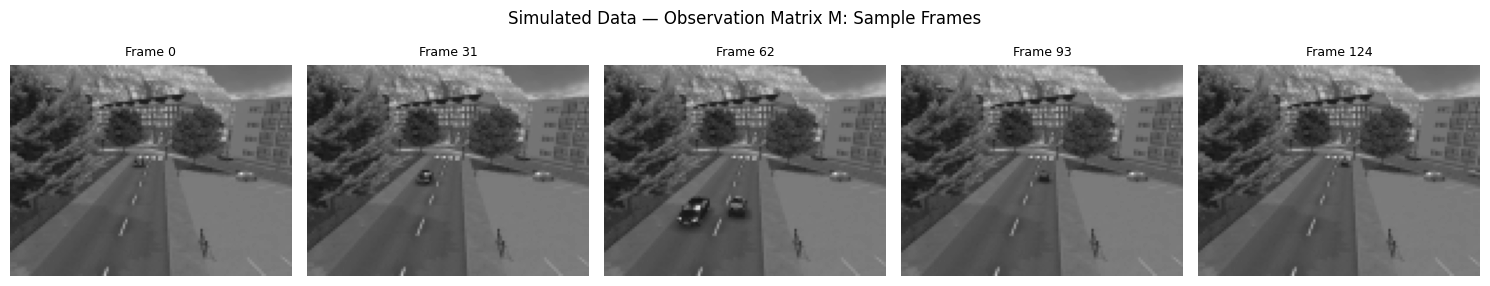

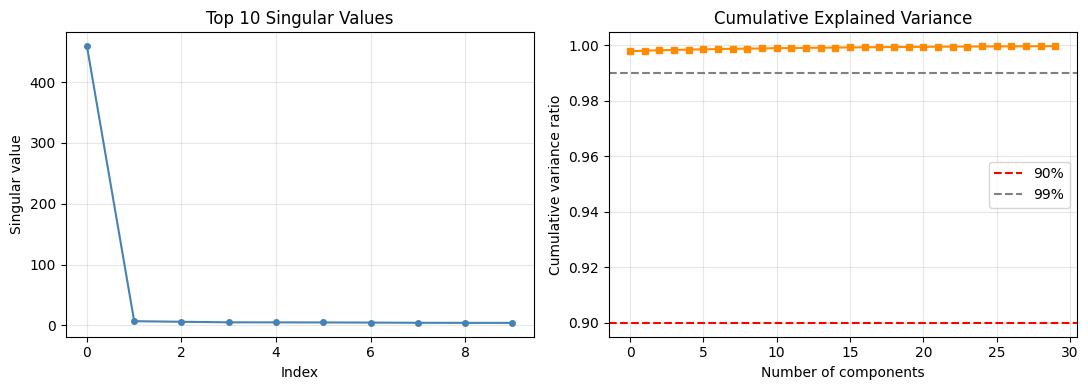

In [9]:
M_sim = extract_frames(CFG.simulated_video_path, CFG, cache_name="M_simulated.npy")
inspect_matrix(M_sim, CFG, title="Simulated Data — Observation Matrix M")


In [10]:
ialm_cfg = IALMConfig(tol=1e-7, max_iter=250, rho=1.2)
rpca_sim = rpca_solver(M_sim, ialm_cfg)


13:55:32 - INFO - IALM starting | shape=(10800,125) | lambda=0.009623 | mu_init=0.002722 | tol=1.00e-07
13:55:32 - INFO -   iter   1 | residual=8.00e-01 | rank(L)=1 | sparsity(S)=1.000 | mu=0.0033
13:55:38 - INFO - IALM converged at iteration 46 | final residual=9.23e-08
13:55:38 - INFO - IALM complete | converged=True | iterations=46 | runtime=5.4s | rank(L)=1 | sparsity(S)=0.9723


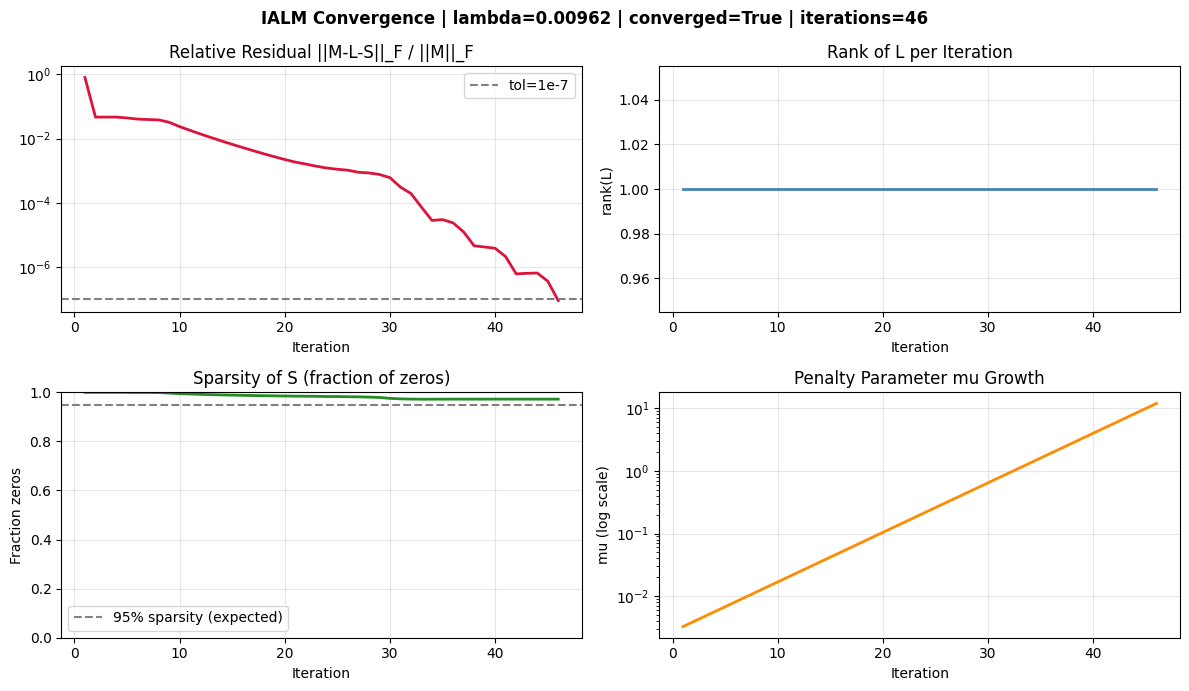

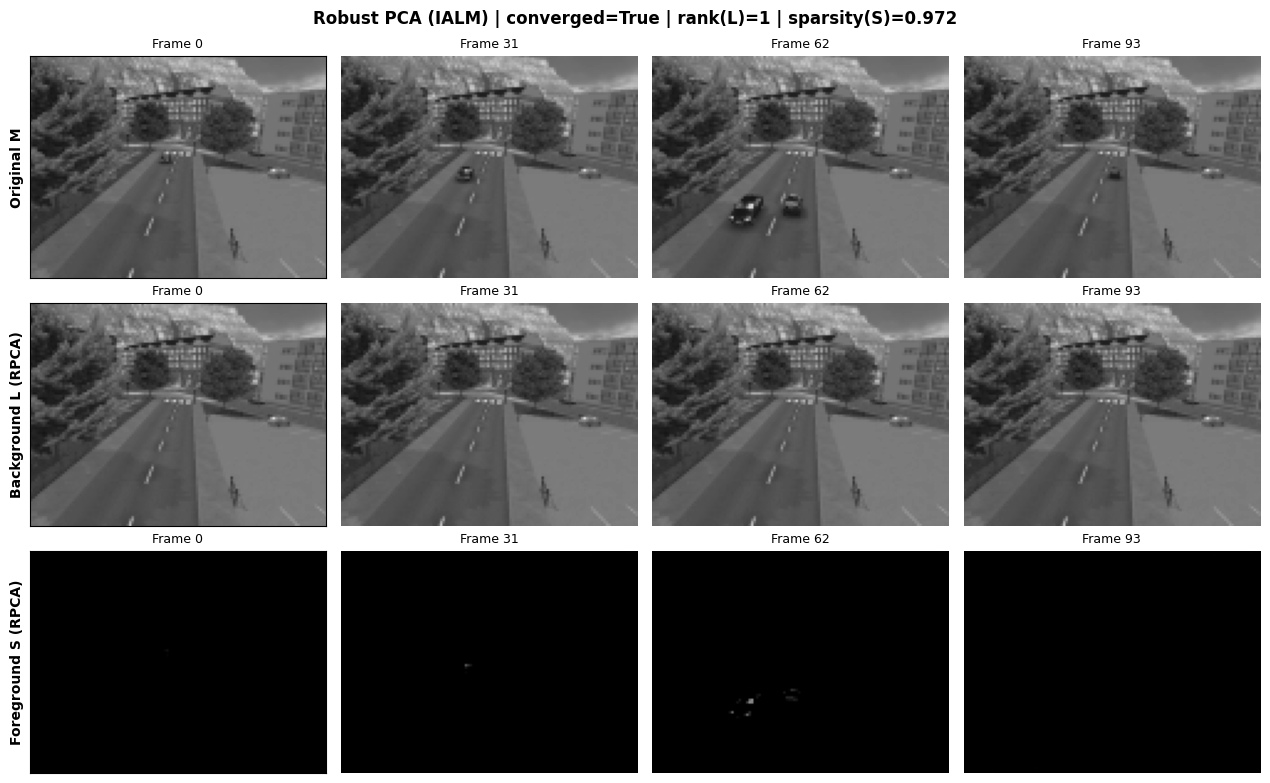

13:55:39 - INFO - -------------------------------------------------------
13:55:39 - INFO - Metrics [RPCA - Simulated]
13:55:39 - INFO -   Frobenius error : 0.048129
13:55:39 - INFO -   MSE             : 0.000027
13:55:39 - INFO -   PSNR            : 45.65 dB
13:55:39 - INFO -   SSIM            : 0.9972
13:55:39 - INFO - -------------------------------------------------------


In [11]:
plot_convergence(rpca_sim.diagnostics)
visualize_rpca_result(rpca_sim, M_sim, CFG)
rpca_metrics_sim = compute_metrics(M_sim, rpca_sim.L, CFG, label="RPCA - Simulated")


## 5. Generalization: Run on Real Data

Same preprocessing, same solver config, same metrics — applied to a real-world video to test whether the low-rank-plus-sparse assumption still holds outside the synthetic benchmark.

13:55:39 - INFO - Loaded cached matrix: M_real.npy | shape=(10800, 50)
13:55:39 - INFO - ==================================================
13:55:39 - INFO - Real Data — Observation Matrix M | shape=(10800, 50) | dtype=float32
13:55:39 - INFO - Min/max: 0.0784 / 0.9922 | Mean/std: 0.4620 / 0.1674
13:55:39 - INFO - Estimated rank (90% variance): 1 | (99% variance): 1
13:55:39 - INFO - ==================================================


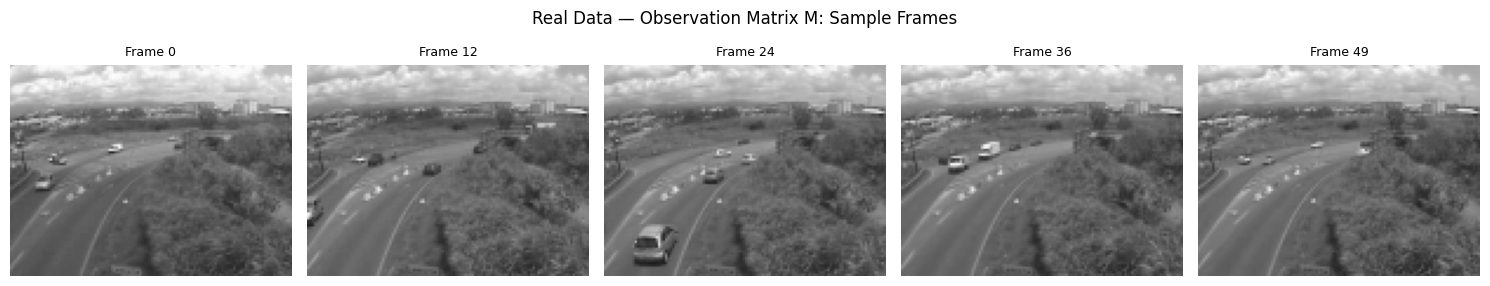

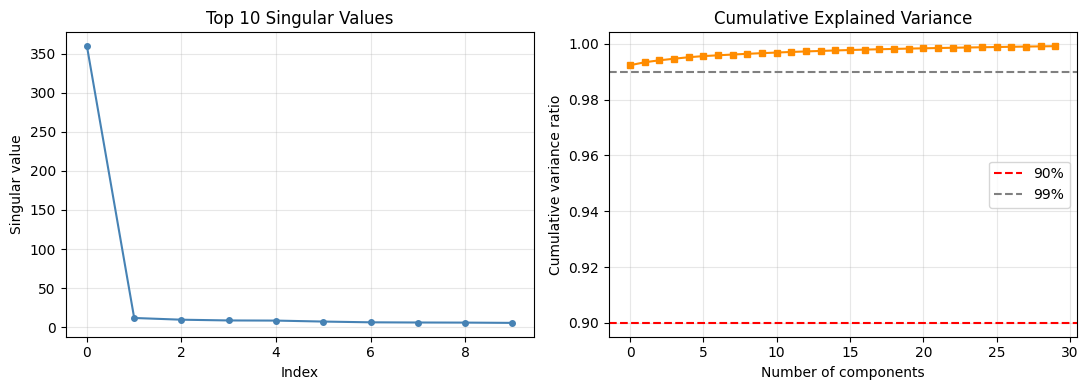

In [12]:
M_real = extract_frames(CFG.real_video_path, CFG, cache_name="M_real.npy")
inspect_matrix(M_real, CFG, title="Real Data — Observation Matrix M")


In [13]:
rpca_real = rpca_solver(M_real, ialm_cfg)


13:55:40 - INFO - IALM starting | shape=(10800,50) | lambda=0.009623 | mu_init=0.003475 | tol=1.00e-07
13:55:40 - INFO -   iter   1 | residual=8.02e-01 | rank(L)=1 | sparsity(S)=1.000 | mu=0.0042
13:55:42 - INFO -   iter  50 | residual=9.32e-06 | rank(L)=25 | sparsity(S)=0.183 | mu=31.6246
13:55:43 - INFO - IALM converged at iteration 70 | final residual=8.95e-08
13:55:43 - INFO - IALM complete | converged=True | iterations=70 | runtime=2.7s | rank(L)=25 | sparsity(S)=0.1741


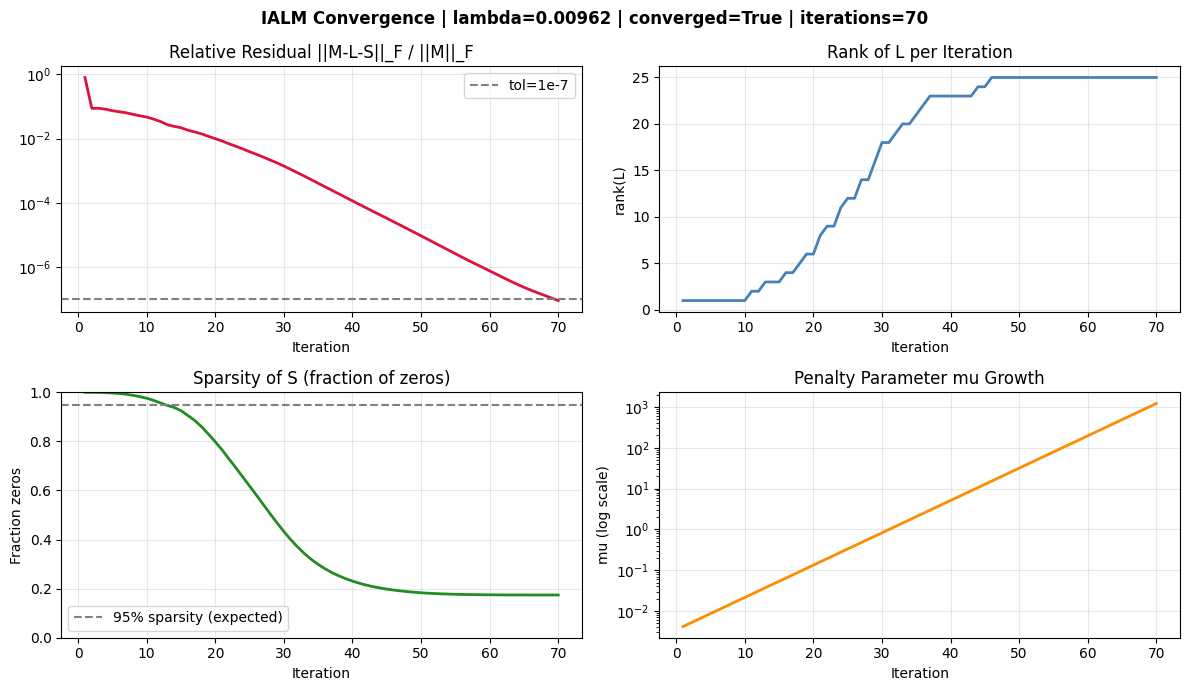

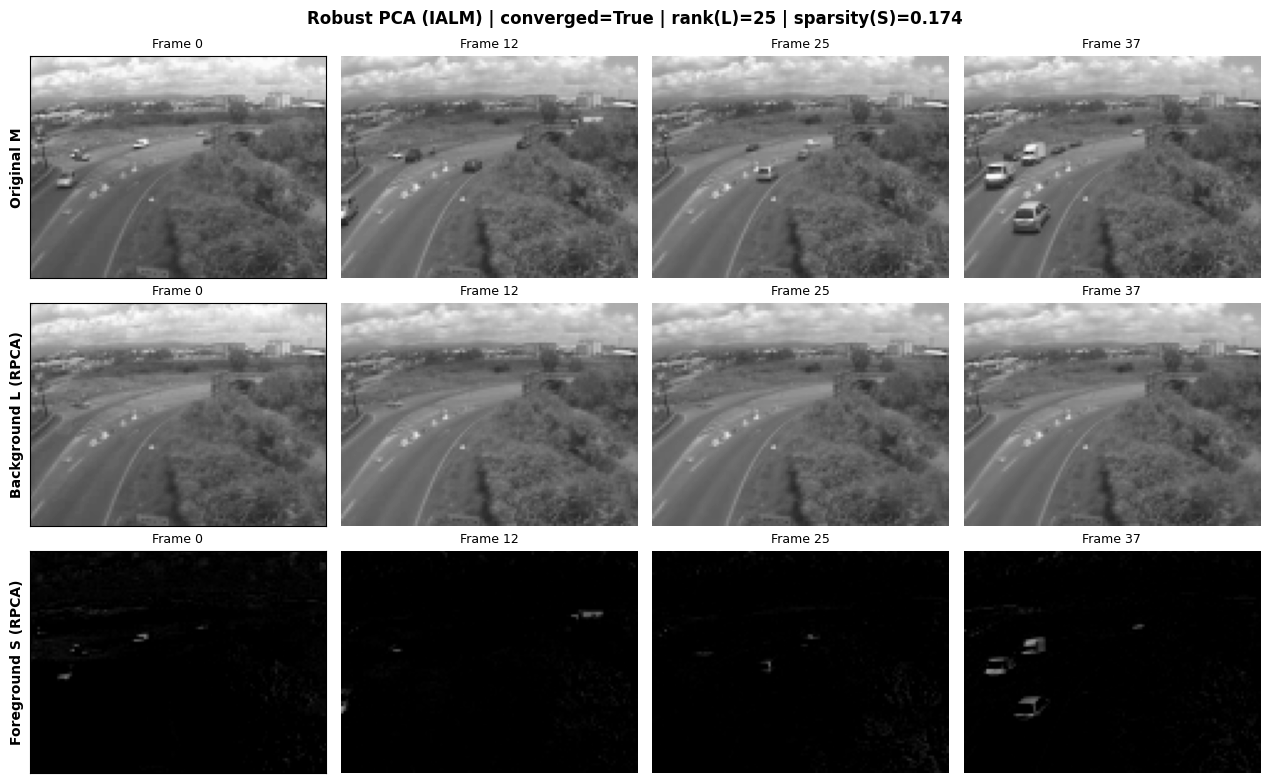

13:55:44 - INFO - -------------------------------------------------------
13:55:44 - INFO - Metrics [RPCA - Real (generalization)]
13:55:45 - INFO -   Frobenius error : 0.080304
13:55:45 - INFO -   MSE             : 0.004419
13:55:45 - INFO -   PSNR            : 23.71 dB
13:55:45 - INFO -   SSIM            : 0.8395
13:55:45 - INFO - -------------------------------------------------------


In [14]:
plot_convergence(rpca_real.diagnostics)
visualize_rpca_result(rpca_real, M_real, CFG)
rpca_metrics_real = compute_metrics(M_real, rpca_real.L, CFG, label="RPCA - Real (generalization)")


## 6. Simulated vs. Generalization: Metrics Comparison

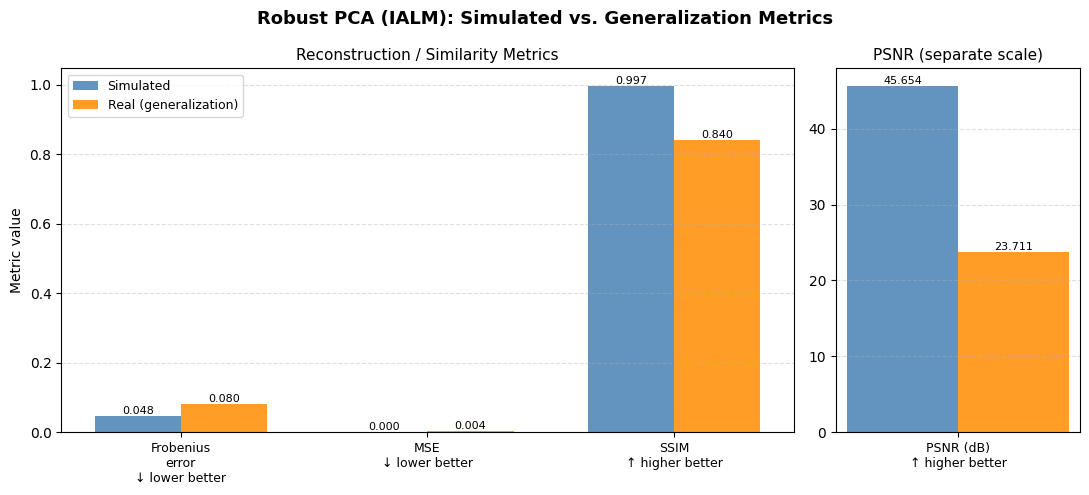

Metric                 Simulated   Real (generalization)
--------------------------------------------------------
Frobenius error           0.0481                  0.0803
MSE                     0.000027                0.004419
PSNR (dB)                  45.65                   23.71
SSIM                      0.9972                  0.8395

Diagnostic                       Simulated          Real
--------------------------------------------------------
Converged                             True          True
Iterations                              46            70
Final rank(L)                            1            25
Final sparsity(S)                   0.9723        0.1741


In [15]:
plot_metrics_comparison(rpca_metrics_sim, rpca_metrics_real, CFG)

print(f"{'Metric':<18}{'Simulated':>14}{'Real (generalization)':>24}")
print("-" * 56)
print(f"{'Frobenius error':<18}{rpca_metrics_sim.frobenius_error:>14.4f}{rpca_metrics_real.frobenius_error:>24.4f}")
print(f"{'MSE':<18}{rpca_metrics_sim.mse:>14.6f}{rpca_metrics_real.mse:>24.6f}")
print(f"{'PSNR (dB)':<18}{rpca_metrics_sim.psnr_db:>14.2f}{rpca_metrics_real.psnr_db:>24.2f}")
ssim_sim_str = f"{rpca_metrics_sim.ssim:.4f}" if rpca_metrics_sim.ssim is not None else "N/A"
ssim_real_str = f"{rpca_metrics_real.ssim:.4f}" if rpca_metrics_real.ssim is not None else "N/A"
print(f"{'SSIM':<18}{ssim_sim_str:>14}{ssim_real_str:>24}")

print()
print(f"{'Diagnostic':<28}{'Simulated':>14}{'Real':>14}")
print("-" * 56)
print(f"{'Converged':<28}{str(rpca_sim.diagnostics.converged):>14}{str(rpca_real.diagnostics.converged):>14}")
print(f"{'Iterations':<28}{rpca_sim.diagnostics.n_iterations:>14}{rpca_real.diagnostics.n_iterations:>14}")
print(f"{'Final rank(L)':<28}{rpca_sim.diagnostics.rank_L[-1]:>14}{rpca_real.diagnostics.rank_L[-1]:>14}")
print(f"{'Final sparsity(S)':<28}{rpca_sim.diagnostics.sparsity_S[-1]:>14.4f}{rpca_real.diagnostics.sparsity_S[-1]:>14.4f}")


## 7. Takeaways

- **A higher Frobenius error / MSE than SVD or PCA on the same data is expected and acceptable** —
  RPCA optimizes $\|L\|_* + \lambda\|S\|_1$, not reconstruction error. Judge RPCA primarily by the
  visual cleanliness of the background (L) and how well isolated moving objects are in the
  foreground (S), not by these reconstruction numbers alone.
- The **convergence diagnostics** (residual decay, rank(L) settling low, sparsity(S) rising toward
  ~0.95+) tell you whether the optimizer actually solved the problem, independent of whether the
  low-rank-plus-sparse model fits the scene well.
- If the real-world generalization run shows a much higher final rank(L), lower sparsity(S), or
  failure to converge compared to the simulated run, that's a sign the real scene's background is
  less stationary (more lighting change, camera motion, etc.) than the synthetic benchmark — the
  core assumption behind RPCA is being stress-tested, not just the solver.
